# Q-Learning for Tic-Tac-Toe

In this notebook we build a Reinforcement Learning agent that learns to play tic-tac-toe by trial and
error, using the **Q-learning** algorithm. We start with the most direct implementation and a random
opponent. The following notebooks improve it step by step.

## The RL Framework

RL is built on a simple interaction loop:

1. **Agent**: our learning algorithm (the tic-tac-toe player)
2. **Environment**: the game world (the board and the other player)
3. **State (S)**: the current situation (board configuration)
4. **Action (A)**: what the agent can do (place its symbol in an empty cell)
5. **Reward (R)**: feedback from the environment (+1 for a win, −1 for a loss, 0 for a draw)

**The loop:** the agent observes a **state**, chooses an **action**, and receives a **reward** and a new
**state**. It learns from that experience, and the loop repeats thousands of times.

<img src="https://gymnasium.farama.org/_images/AE_loop.png" alt="RL Loop" width="360">

## Understanding Q-Learning

**Q-learning** builds a table that estimates how good each move is in every game situation.

### The Q-Table

Think of the Q-table as a spreadsheet:
- **Rows**: board configurations (states)
- **Columns**: moves (actions: cells 1-9)
- **Values**: Q-values, the expected return of making that move in that situation

A high Q-value (e.g. +0.8) means "this move tends to lead to a win", a low one (e.g. −0.5) "this move
tends to lead to a loss", and 0 is the initial value of anything not tried yet.

### The Update Rule (Bellman Equation)

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

- $Q(s, a)$: current estimate for action $a$ in state $s$
- $\alpha$: **learning rate** (0-1), how far each update moves the estimate
- $r$: **reward** received after the action
- $\gamma$: **discount factor** (0-1), how much future rewards are worth
- $s'$: the **next state**, where the agent will choose its next action $a'$
- $\max_{a'} Q(s', a')$: the value of the best move available from $s'$
- The bracket is the **temporal-difference (TD) error**: the gap between the new evidence and the old estimate

*"Move my estimate of this move towards the reward I just got plus the value of the best move from
where I ended up."*

### Exploration vs Exploitation

- **Exploit**: use what you know (pick the move with the highest Q-value)
- **Explore**: try something else (maybe there is a better move)

The **ε-greedy policy** explores with probability $\epsilon$ and exploits with probability
$1 - \epsilon$. We start with $\epsilon = 1.0$ (pure exploration) and decay it towards $0.05$.

## Tic-Tac-Toe as an RL Problem

### State Space

**State** = current board configuration

```
Board positions:        Example state:
 1 | 2 | 3               X | O | 3
-----------             -----------
 4 | 5 | 6               X | 5 | 6
-----------             -----------
 7 | 8 | 9               7 | 8 | 9
```

We represent it as a tuple: `('X', 'O', None, 'X', None, None, None, None, None)`.

There are at most $3^9 = 19{,}683$ boards (each cell is X, O or empty), and many of them are unreachable
in a real game. The agent only stores the ones it actually visits.

### Action Space

**Action** = the cell where the agent places its symbol (1-9). Only empty cells are valid.

### Reward Structure

- **Win**: +1.0
- **Loss**: −1.0
- **Draw**: 0.0
- **Each move**: −0.01, a small penalty that makes quicker wins slightly better than slower ones

### Winning Conditions

8 lines: 3 rows (1,2,3), (4,5,6), (7,8,9); 3 columns (1,4,7), (2,5,8), (3,6,9); 2 diagonals (1,5,9), (3,5,7).

## Setup

The reusable code lives in the `core` package, one folder up (`04_qlearning/core/`). We add that folder
to Python's import path so that `from core... import ...` works from this notebook. A fixed random seed
makes the results reproducible.

In [1]:
import sys
import random
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
random.seed(42)

## The Environment

`TicTacToeEnvironment` (in `core/environment.py`) manages the board, validates moves and detects the end of
the game. The board is a dictionary `{1..9: 'X' | 'O' | None}`.

In [2]:
from core.environment import TicTacToeEnvironment

env = TicTacToeEnvironment()
env.make_move(5, 'X')
env.make_move(1, 'O')
env.make_move(9, 'X')
env.display()



O | 2 | 3
---------
4 | X | 6
---------
7 | 8 | X




In [3]:
print(f"Available actions: {env.get_available_actions()}")
print(f"Game over: {env.is_game_over()}")

Available actions: [2, 3, 4, 6, 7, 8]
Game over: (False, None)


## The Q-Learning Agent

`QLearningAgent` (in `core/agents/q_learning_agent.py`):

1. **Stores knowledge** in a Q-table: a dictionary `{(state, action): Q-value}`
2. **Chooses actions** with the ε-greedy policy (`choose_action`)
3. **Learns from experience** with the update rule above (`learn`)

It also keeps an **episode history** with the (state, action) pairs it has played, so that `learn()` knows
which Q-value to update.

In [4]:
from core.agents.q_learning_agent import QLearningAgent

agent = QLearningAgent(symbol='X', learning_rate=0.1, discount_factor=0.9, epsilon=0.3)
print(f"Symbol: {agent.symbol} | α={agent.learning_rate} | γ={agent.discount_factor} | ε={agent.epsilon}")

Symbol: X | α=0.1 | γ=0.9 | ε=0.3


This is the update itself. `next_board=None` marks the end of the game, where there is no future value.

In [5]:
import inspect

print(inspect.getsource(QLearningAgent.learn))

    def learn(self, reward: float, next_board: dict[int, str | None] | None = None) -> None:
        """
        Update Q-value using Q-learning formula (Bellman equation).

        Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]

        This single method handles BOTH cases:
        - Game continues: next_board is a dict, we calculate max future Q-value
        - Game ends: next_board is None, so max_future_q = 0 (terminal state)

        Args:
            reward: Immediate reward received
                   - Final rewards: +1.0 (win), -1.0 (loss), 0.0 (draw)
                   - Intermediate: -0.01 (small penalty per move)
            next_board: Board at this agent's next turn, i.e. after the opponent's reply.
                       - If None: Game ended (terminal state)
                       - If dict: Game continues (non-terminal state)
        """
        if not self.training_mode or not self.episode_history:
            return

        # Get the last state-action pair
      

## Training the Agent

The agent plays thousands of games against an opponent that picks a random empty cell.

- **Episodes**: 20,000 games; who starts is chosen at random each game
- **Learning rate (α)**: 0.1
- **Discount factor (γ)**: 0.9
- **ε**: starts at 1.0 and is multiplied by 0.9995 after every game, down to a minimum of 0.05

### The training loop

The most direct way to write the game loop is to update the agent **right after each of its own moves**:

- If its move ends the game, it learns from the final reward (+1 for a win, 0 for a draw).
- Otherwise it learns from the step penalty, taking the board its move produced as the next state $s'$.

In [6]:
def play_training_game(agent: QLearningAgent, env: TicTacToeEnvironment, agent_first: bool = True) -> str:
    """Play one game against a random opponent, updating the agent after each of its moves."""
    env.reset()
    agent.reset_episode()

    agent_symbol = agent.symbol
    opponent_symbol = 'O' if agent_symbol == 'X' else 'X'
    current_player = agent_symbol if agent_first else opponent_symbol

    while True:
        available = env.get_available_actions()
        if current_player == agent_symbol:
            move = agent.choose_action(env.board, available)
        else:
            move = random.choice(available)

        env.make_move(move, current_player)
        is_over, result = env.is_game_over()

        if current_player == agent_symbol:
            if is_over:
                # The agent's move ended the game: learn from the final reward
                reward = 1.0 if result == agent_symbol else 0.0
                agent.learn(reward=reward, next_board=None)
                return result
            # The game goes on: learn from the step penalty and the board the move produced
            agent.learn(reward=-0.01, next_board=env.board)
        elif is_over:
            return result

        current_player = opponent_symbol if current_player == agent_symbol else agent_symbol

In [7]:
N_EPISODES = 20000
EVAL_EVERY = 2000
EPSILON_START, EPSILON_END, EPSILON_DECAY = 1.0, 0.05, 0.9995

agent = QLearningAgent(symbol='X', learning_rate=0.1, discount_factor=0.9, epsilon=EPSILON_START)
env = TicTacToeEnvironment()

history = {'wins': [], 'losses': [], 'draws': [], 'epsilon': []}
results = {'X': 0, 'O': 0, 'draw': 0}
epsilon = EPSILON_START

for episode in range(1, N_EPISODES + 1):
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    agent.set_epsilon(epsilon)

    result = play_training_game(agent, env, agent_first=random.choice([True, False]))
    results[result] += 1

    if episode % EVAL_EVERY == 0:
        history['wins'].append(results['X'] / EVAL_EVERY)
        history['losses'].append(results['O'] / EVAL_EVERY)
        history['draws'].append(results['draw'] / EVAL_EVERY)
        history['epsilon'].append(epsilon)
        print(f"Episode {episode}: win {history['wins'][-1]:.2f} | loss {history['losses'][-1]:.2f} | "
              f"draw {history['draws'][-1]:.2f} | ε={epsilon:.3f}")
        results = {'X': 0, 'O': 0, 'draw': 0}

print(f"Q-table: {len(agent.q_table)} entries, {agent.get_stats()['unique_states']} states")

Episode 2000: win 0.47 | loss 0.41 | draw 0.12 | ε=0.368
Episode 4000: win 0.54 | loss 0.36 | draw 0.10 | ε=0.135


Episode 6000: win 0.62 | loss 0.29 | draw 0.08 | ε=0.050
Episode 8000: win 0.68 | loss 0.25 | draw 0.07 | ε=0.050


Episode 10000: win 0.72 | loss 0.22 | draw 0.06 | ε=0.050
Episode 12000: win 0.73 | loss 0.22 | draw 0.06 | ε=0.050


Episode 14000: win 0.73 | loss 0.22 | draw 0.05 | ε=0.050
Episode 16000: win 0.73 | loss 0.22 | draw 0.04 | ε=0.050


Episode 18000: win 0.72 | loss 0.23 | draw 0.05 | ε=0.050
Episode 20000: win 0.74 | loss 0.21 | draw 0.06 | ε=0.050
Q-table: 11630 entries, 4402 states


The rates above are measured **during training**, so they include the random moves made while exploring.

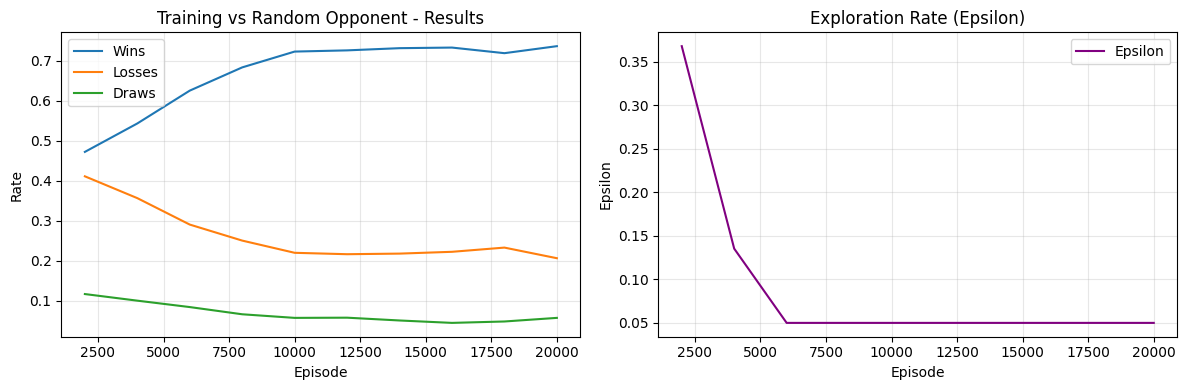

In [8]:
from core.training import plot_training_history

plot_training_history(history, eval_every=EVAL_EVERY, title="Training vs Random Opponent")

## Evaluation

To measure what the agent has really learned, we switch learning and exploration off (greedy policy) and
play 1,000 games. `evaluate_agent` (from `core.training`) does exactly that and picks the starter at random.
Since the agent does not learn during evaluation, the way the loop updates Q-values does not matter here.

In [9]:
from core.training import evaluate_agent
from core.agents.random_agent import RandomAgent

results_vs_random = evaluate_agent(agent, RandomAgent('O'), n_games=1000)
print(f"Win {results_vs_random['win_rate']:.1%} | Loss {results_vs_random['loss_rate']:.1%} | "
      f"Draw {results_vs_random['draw_rate']:.1%}")

Win 75.6% | Loss 20.7% | Draw 3.7%


Against a random opponent the greedy agent wins 75.6% of the games but **loses 20.7%**. A random opponent
makes plenty of mistakes, so losing one game in five against it means the agent has not learned even basic
defense.

## Visualizing Q-Values

Let's look inside the Q-table. The helper below prints the Q-value of every empty cell for a given board.

In [10]:
def show_q_values(agent: QLearningAgent, board: dict[int, str | None]) -> None:
    """Print the board with the Q-value of every empty cell, from `agent`'s point of view."""
    state = agent.get_state_key(board)
    for row in range(3):
        cells = []
        for col in range(3):
            cell = row * 3 + col + 1
            cells.append(f"  {board[cell]}   " if board[cell] else f"{agent.get_q_value(state, cell):+.2f}")
        print(" | ".join(cells))
        if row < 2:
            print("-" * 23)

**Winning move**: X has cells 1 and 2, so cell 3 wins immediately.

In [11]:
winning_board = {1: 'X', 2: 'X', 3: None,
                 4: None, 5: 'O', 6: None,
                 7: 'O', 8: None, 9: None}
show_q_values(agent, winning_board)

  X    |   X    | +0.77
-----------------------
+0.00 |   O    | +0.00
-----------------------
  O    | -0.00 | +0.00


**Blocking move**: O threatens to complete the 3-5-7 diagonal, so X must play 3. Any other move lets the
opponent win.

In [12]:
blocking_board = {1: 'X', 2: None, 3: None,
                  4: None, 5: 'O', 6: None,
                  7: 'O', 8: 'X', 9: None}
show_q_values(agent, blocking_board)

  X    | -0.00 | -0.00
-----------------------
-0.00 |   O    | -0.00
-----------------------
  O    |   X    | -0.00


The agent clearly recognizes the winning move: cell 3 has a high Q-value and the rest are close to 0.

In the blocking position, however, **every Q-value is about zero**. Only the tiny −0.01 step penalties
show up. The agent has no idea that every cell except 3 loses the game, so its choice there is a coin toss
among equal values.

## Why Didn't the Agent Learn Perfect Play?

A common explanation blames the opponent. A random player only completes its threat with probability
1 / (number of empty cells), so a missed block is rarely punished and the agent sees few losses. That
effect is real, and notebooks 03-05 explore stronger opponents.

But the blocking position above shows something stranger. The Q-values of the losing moves are not
slightly negative; they are **essentially zero**, even after 20,000 games in which the agent lost about one
game in five. Losses happen, yet they leave no trace in the Q-table.

That points at the training loop rather than at the opponent. Notebook 02 investigates it.

## Save and Load the Q-Table

The Q-table is a plain dictionary, so it can be saved with `pickle` and reloaded later without retraining.
The `.pkl` files are ignored by Git: they can always be regenerated.

In [13]:
agent.save('q_table_basics.pkl')

reloaded_agent = QLearningAgent(symbol='X', training_mode=False)
reloaded_agent.load('q_table_basics.pkl')
print(reloaded_agent.q_table == agent.q_table)

Q-table saved to q_table_basics.pkl
Total state-action pairs learned: 11630
Q-table loaded from q_table_basics.pkl
Total state-action pairs: 11630
True


## Summary

- The **Q-table** maps (state, action) pairs to estimated returns.
- The **update rule** moves each estimate towards the reward plus the discounted value of the next state.
- The **ε-greedy policy** balances exploration and exploitation, and ε decays during training.
- An agent trained against a random opponent learns to win often, but it still loses games it should not.

Next notebook: before blaming the opponent, we inspect the training loop itself.